In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn import tree
import optuna
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [4]:
def print_classification_metrics(y_true, y_pred):
    print(f'Accuracy: {accuracy_score(y_true, y_pred)}')
    print(classification_report(y_true, y_pred))

In [5]:
data = pd.read_csv('data/k4_eda.csv')
y = data['Fire Alarm']
X = data.drop(columns=['Fire Alarm', 'UTC'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

### DecisionTreeClassifier

In [6]:
reg = DecisionTreeClassifier(max_depth=6, criterion='gini', random_state=42)
reg.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=6, random_state=42)

In [7]:
y_pred = reg.predict(X_test)

print_classification_metrics(y_test, y_pred)

Accuracy: 0.9992961711711712
              precision    recall  f1-score   support

       False       0.99      1.00      0.99       780
        True       1.00      1.00      1.00     13428

    accuracy                           1.00     14208
   macro avg       1.00      1.00      1.00     14208
weighted avg       1.00      1.00      1.00     14208



#### Подбор гиперпараметров

In [8]:
def objective(trial):
    max_depth = trial.suggest_int('max_depth', 1, 32)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 20)
    max_features = trial.suggest_categorical('max_features', [None, 'sqrt', 'log2'])
    model = DecisionTreeClassifier(
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        criterion='gini',
        random_state=42
    )
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    return scores.mean()

# study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=50)

In [ ]:
# reg = DecisionTreeClassifier(**study.best_params, criterion='gini', random_state=42)
reg = DecisionTreeClassifier(max_depth=32, min_samples_split=10, random_state=42)
reg.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=32, min_samples_split=10, random_state=42)

In [11]:
import pickle


model_path = "reg.pkl"
try:
    with open(model_path, 'wb') as file:
        pickle.dump(reg, file)
    print(f"Модель успешно сохранена в {model_path}")
except Exception as e:
    print(f"Ошибка при сохранении модели: {e}")


with open(model_path, 'rb') as file:
    loaded_model = pickle.load(file)
print("Модель успешно загружена")

Модель успешно сохранена в reg.pkl
Модель успешно загружена


In [10]:
y_pred = reg.predict(X_test)

print_classification_metrics(y_test, y_pred)

Accuracy: 0.9997184684684685
              precision    recall  f1-score   support

       False       1.00      0.99      1.00       780
        True       1.00      1.00      1.00     13428

    accuracy                           1.00     14208
   macro avg       1.00      1.00      1.00     14208
weighted avg       1.00      1.00      1.00     14208



### BaggingClassifier

In [72]:
base_classifier = DecisionTreeClassifier(max_depth=6, criterion='gini', random_state=42)
bg_reg = BaggingClassifier(
    estimator=base_classifier,
    n_estimators=100,
    random_state=42
)
bg_reg.fit(X_train, y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=6,
                                                   random_state=42),
                  n_estimators=100, random_state=42)

In [73]:
y_pred = bg_reg.predict(X_test)

print_classification_metrics(y_test, y_pred)

Accuracy: 0.9913237758331782
              precision    recall  f1-score   support

       False       0.99      1.00      0.99     13428
        True       1.00      0.99      0.99     13427

    accuracy                           0.99     26855
   macro avg       0.99      0.99      0.99     26855
weighted avg       0.99      0.99      0.99     26855



#### Подбор гиперпараметров

In [74]:
def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 10, 200)
    max_samples = trial.suggest_float('max_samples', 0.1, 1.0)
    max_features = trial.suggest_float('max_features', 0.1, 1.0)
    bootstrap = trial.suggest_categorical('bootstrap', [True, False])
    model = BaggingClassifier(
        estimator=DecisionTreeClassifier(criterion='gini', random_state=42),
        n_estimators=n_estimators,
        max_samples=max_samples,
        max_features=max_features,
        bootstrap=bootstrap,
        random_state=42
    )
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    return scores.mean()

# study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=50)

In [12]:
# bg_reg = BaggingClassifier(
#     estimator=DecisionTreeClassifier(criterion='gini', random_state=42),
#     **study.best_params,
#     random_state=42
# )
bg_reg = BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                  max_features=0.851628349029492,
                  max_samples=0.9483801126143273, n_estimators=63,
                  random_state=42)
bg_reg.fit(X_train, y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                  max_features=0.851628349029492,
                  max_samples=0.9483801126143273, n_estimators=63,
                  random_state=42)

In [13]:
import pickle


model_path = "bg_reg.pkl"
try:
    with open(model_path, 'wb') as file:
        pickle.dump(bg_reg, file)
    print(f"Модель успешно сохранена в {model_path}")
except Exception as e:
    print(f"Ошибка при сохранении модели: {e}")


with open(model_path, 'rb') as file:
    loaded_model = pickle.load(file)
print("Модель успешно загружена")

Модель успешно сохранена в bg_reg.pkl
Модель успешно загружена


In [14]:
y_pred = bg_reg.predict(X_test)

print_classification_metrics(y_test, y_pred)

Accuracy: 0.9999296171171171
              precision    recall  f1-score   support

       False       1.00      1.00      1.00       780
        True       1.00      1.00      1.00     13428

    accuracy                           1.00     14208
   macro avg       1.00      1.00      1.00     14208
weighted avg       1.00      1.00      1.00     14208



### GradientBoostingClassifier

In [77]:
gb_reg = GradientBoostingClassifier(max_depth=6, n_estimators=100, random_state=42)
gb_reg.fit(X_train, y_train)

GradientBoostingClassifier(max_depth=6, random_state=42)

In [78]:
y_pred = gb_reg.predict(X_test)

print_classification_metrics(y_test, y_pred)

Accuracy: 0.9996648668776764
              precision    recall  f1-score   support

       False       1.00      1.00      1.00     13428
        True       1.00      1.00      1.00     13427

    accuracy                           1.00     26855
   macro avg       1.00      1.00      1.00     26855
weighted avg       1.00      1.00      1.00     26855



#### Подбор гиперпараметров

In [79]:
def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3)
    max_depth = trial.suggest_int('max_depth', 1, 10)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 20)
    subsample = trial.suggest_float('subsample', 0.5, 1.0)
    model = GradientBoostingClassifier(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        subsample=subsample,
        random_state=42
    )
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    return scores.mean()

# study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=50)

In [16]:
# gb_reg = GradientBoostingClassifier(**study.best_params, random_state=42)
gb_reg = GradientBoostingClassifier(learning_rate=0.20986382392075253, max_depth=5,
                                    min_samples_leaf=13, min_samples_split=13,
                                    n_estimators=167, random_state=42,
                                    subsample=0.6379331115710877)
gb_reg.fit(X_train, y_train)

GradientBoostingClassifier(learning_rate=0.20986382392075253, max_depth=5,
                           min_samples_leaf=13, min_samples_split=13,
                           n_estimators=167, random_state=42,
                           subsample=0.6379331115710877)

In [17]:
import pickle


model_path = "gb_reg.pkl"
try:
    with open(model_path, 'wb') as file:
        pickle.dump(gb_reg, file)
    print(f"Модель успешно сохранена в {model_path}")
except Exception as e:
    print(f"Ошибка при сохранении модели: {e}")


with open(model_path, 'rb') as file:
    loaded_model = pickle.load(file)
print("Модель успешно загружена")

Модель успешно сохранена в gb_reg.pkl
Модель успешно загружена


In [81]:
y_pred = gb_reg.predict(X_test)

print_classification_metrics(y_test, y_pred)

Accuracy: 0.9998882889592254
              precision    recall  f1-score   support

       False       1.00      1.00      1.00     13428
        True       1.00      1.00      1.00     13427

    accuracy                           1.00     26855
   macro avg       1.00      1.00      1.00     26855
weighted avg       1.00      1.00      1.00     26855



### StackingClassifier

In [18]:
estimators = [
    ('dt', DecisionTreeClassifier(max_depth=3, criterion='gini', random_state=42)),
    ('lr', LogisticRegression(random_state=42))
]
stack_reg = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression(random_state=42))
stack_reg.fit(X_train, y_train)

p:\Python\ML1\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
p:\Python\ML1\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_o

StackingClassifier(estimators=[('dt',
                                DecisionTreeClassifier(max_depth=3,
                                                       random_state=42)),
                               ('lr', LogisticRegression(random_state=42))],
                   final_estimator=LogisticRegression(random_state=42))

In [19]:
import pickle


model_path = "stack_reg.pkl"
try:
    with open(model_path, 'wb') as file:
        pickle.dump(stack_reg, file)
    print(f"Модель успешно сохранена в {model_path}")
except Exception as e:
    print(f"Ошибка при сохранении модели: {e}")


with open(model_path, 'rb') as file:
    loaded_model = pickle.load(file)
print("Модель успешно загружена")

Модель успешно сохранена в stack_reg.pkl
Модель успешно загружена


In [83]:
y_pred = stack_reg.predict(X_test)

print_classification_metrics(y_test, y_pred)

Accuracy: 0.9695401228821449
              precision    recall  f1-score   support

       False       0.95      0.99      0.97     13428
        True       0.99      0.95      0.97     13427

    accuracy                           0.97     26855
   macro avg       0.97      0.97      0.97     26855
weighted avg       0.97      0.97      0.97     26855



#### Подбор гиперпараметров

In [84]:
def objective(trial):
    dt_max_depth = trial.suggest_int('dt_max_depth', 1, 10)
    dt_min_samples_split = trial.suggest_int('dt_min_samples_split', 2, 20)
    C = trial.suggest_float('C', 0.1, 10.0)
    estimators = [
        ('dt', DecisionTreeClassifier(max_depth=dt_max_depth, min_samples_split=dt_min_samples_split, criterion='gini', random_state=42)),
        ('lr', LogisticRegression(random_state=42))
    ]
    meta_model = LogisticRegression(C=C, random_state=42)
    model = StackingClassifier(estimators=estimators, final_estimator=meta_model)
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    return scores.mean()

# study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=50)

In [85]:
# best_params = study.best_params
# best_estimators = [
#     ('dt', DecisionTreeClassifier(
#         max_depth=best_params['dt_max_depth'], min_samples_split=best_params['dt_min_samples_split'], criterion='gini', random_state=42)),
#     ('lr', LogisticRegression(random_state=42))
# ]
# best_meta_model = LogisticRegression(C=best_params['C'], random_state=42)
# stack_reg = StackingClassifier(
#     estimators=best_estimators, final_estimator=best_meta_model)
StackingClassifier(estimators=[('dt',
                                DecisionTreeClassifier(max_depth=10,
                                                       min_samples_split=3,
                                                       random_state=42)),
                               ('lr', LogisticRegression(random_state=42))],
                   final_estimator=LogisticRegression(C=5.7354339692365475,
                                                      random_state=42))
stack_reg.fit(X_train, y_train)

p:\Python\ML1\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
p:\Python\ML1\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_o

StackingClassifier(estimators=[('dt',
                                DecisionTreeClassifier(max_depth=3,
                                                       random_state=42)),
                               ('lr', LogisticRegression(random_state=42))],
                   final_estimator=LogisticRegression(random_state=42))

In [86]:
y_pred = stack_reg.predict(X_test)

print_classification_metrics(y_test, y_pred)

Accuracy: 0.9695401228821449
              precision    recall  f1-score   support

       False       0.95      0.99      0.97     13428
        True       0.99      0.95      0.97     13427

    accuracy                           0.97     26855
   macro avg       0.97      0.97      0.97     26855
weighted avg       0.97      0.97      0.97     26855



### CatBoostClassifier

In [87]:
cat_model = CatBoostClassifier(
    iterations=100,
    learning_rate=0.1,
    depth=3,
    random_seed=42,
    verbose=0
)
cat_model.fit(X_train, y_train)

In [88]:
y_pred = cat_model.predict(X_test)

print_classification_metrics(y_test, y_pred)

Accuracy: 0.9983243343883821
              precision    recall  f1-score   support

       False       1.00      1.00      1.00     13428
        True       1.00      1.00      1.00     13427

    accuracy                           1.00     26855
   macro avg       1.00      1.00      1.00     26855
weighted avg       1.00      1.00      1.00     26855



#### Подбор гиперпараметров

In [89]:
def objective(trial):
    iterations = trial.suggest_int('iterations', 50, 300)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3)
    depth = trial.suggest_int('depth', 1, 10)
    l2_leaf_reg = trial.suggest_float('l2_leaf_reg', 1, 10)
    bagging_temperature = trial.suggest_float('bagging_temperature', 0, 1)
    model = CatBoostClassifier(
        iterations=iterations,
        learning_rate=learning_rate,
        depth=depth,
        l2_leaf_reg=l2_leaf_reg,
        bagging_temperature=bagging_temperature,
        random_seed=42,
        verbose=0
    )
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    return scores.mean()

# study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=50)

In [21]:
# cat_model = CatBoostClassifier(**study.best_params, random_seed=42, verbose=0)
cat_model = CatBoostClassifier(iterations=257, learning_rate=0.12647364102783587, depth=8,
                               l2_leaf_reg=2.52805991333303, bagging_temperature=0.4415643564619991, random_seed=42, verbose=0)
cat_model.fit(X_train, y_train)

In [23]:
import pickle


model_path = "cat_model.pkl"
try:
    with open(model_path, 'wb') as file:
        pickle.dump(cat_model, file)
    print(f"Модель успешно сохранена в {model_path}")
except Exception as e:
    print(f"Ошибка при сохранении модели: {e}")


with open(model_path, 'rb') as file:
    loaded_model = pickle.load(file)
print("Модель успешно загружена")

Модель успешно сохранена в cat_model.pkl
Модель успешно загружена


In [22]:
y_pred = cat_model.predict(X_test)

print_classification_metrics(y_test, y_pred)

Accuracy: 0.9999296171171171
              precision    recall  f1-score   support

       False       1.00      1.00      1.00       780
        True       1.00      1.00      1.00     13428

    accuracy                           1.00     14208
   macro avg       1.00      1.00      1.00     14208
weighted avg       1.00      1.00      1.00     14208



### XGBClassifier

In [92]:
X_train_copy = X_train.copy()
X_train_copy.columns = X_train_copy.columns.str.replace(r"[\[\]<>]", "", regex=True)

X_test_copy = X_test.copy()
X_test_copy.columns = X_test_copy.columns.str.replace(r"[\[\]<>]", "", regex=True)

In [93]:
xgb_model = XGBClassifier(
    max_depth=3,
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    verbosity=0
)
xgb_model.fit(X_train_copy, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [94]:
y_pred = xgb_model.predict(X_test_copy)

print_classification_metrics(y_test, y_pred)

Accuracy: 0.9991063116738038
              precision    recall  f1-score   support

       False       1.00      1.00      1.00     13428
        True       1.00      1.00      1.00     13427

    accuracy                           1.00     26855
   macro avg       1.00      1.00      1.00     26855
weighted avg       1.00      1.00      1.00     26855



#### Подбор гиперпараметров

In [95]:
def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    max_depth = trial.suggest_int('max_depth', 1, 10)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3)
    subsample = trial.suggest_float('subsample', 0.5, 1.0)
    colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0)
    gamma = trial.suggest_float('gamma', 0, 5)
    reg_alpha = trial.suggest_float('reg_alpha', 0, 10)
    reg_lambda = trial.suggest_float('reg_lambda', 0, 10)
    model = XGBClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        gamma=gamma,
        reg_alpha=reg_alpha,
        reg_lambda=reg_lambda,
        random_state=42,
        verbosity=0
    )
    scores = cross_val_score(model, X_train_copy, y_train, cv=5, scoring='accuracy')
    return scores.mean()

# study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=50)

In [96]:
# xgb_model = XGBClassifier(**study.best_params, random_state=42, verbosity=0)
xgb_model = XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6451392746258892, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=0.31528866591436505, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.0751536822610973,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, monotone_constraints=None,
              multi_strategy=None, n_estimators=196, n_jobs=None,
              num_parallel_tree=None)
xgb_model.fit(X_train_copy, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6451392746258892, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=0.31528866591436505, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.0751536822610973,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=196, n_jobs=None,
              num_parallel_tree=None, ...)

In [97]:
y_pred = xgb_model.predict(X_test_copy)

print_classification_metrics(y_test, y_pred)

Accuracy: 0.9998138149320425
              precision    recall  f1-score   support

       False       1.00      1.00      1.00     13428
        True       1.00      1.00      1.00     13427

    accuracy                           1.00     26855
   macro avg       1.00      1.00      1.00     26855
weighted avg       1.00      1.00      1.00     26855



### LGBMClassifier

In [98]:
lgb_model = LGBMClassifier(
    max_depth=3,
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    verbose=-1
)
lgb_model.fit(X_train_copy, y_train)

LGBMClassifier(max_depth=3, random_state=42, verbose=-1)

In [99]:
y_pred = lgb_model.predict(X_test)

print_classification_metrics(y_test, y_pred)

Accuracy: 0.9992180227145783
              precision    recall  f1-score   support

       False       1.00      1.00      1.00     13428
        True       1.00      1.00      1.00     13427

    accuracy                           1.00     26855
   macro avg       1.00      1.00      1.00     26855
weighted avg       1.00      1.00      1.00     26855



#### Подбор гиперпараметров

In [100]:
def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    max_depth = trial.suggest_int('max_depth', 1, 10)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3)
    num_leaves = trial.suggest_int('num_leaves', 2, 100)
    min_child_samples = trial.suggest_int('min_child_samples', 1, 20)
    subsample = trial.suggest_float('subsample', 0.5, 1.0)
    colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0)
    reg_alpha = trial.suggest_float('reg_alpha', 0, 10)
    reg_lambda = trial.suggest_float('reg_lambda', 0, 10)
    model = LGBMClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        num_leaves=num_leaves,
        min_child_samples=min_child_samples,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        reg_alpha=reg_alpha,
        reg_lambda=reg_lambda,
        random_state=42,
        verbose=-1
    )
    scores = cross_val_score(model, X_train_copy, y_train, cv=5, scoring='accuracy')
    return scores.mean()

# study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=50)

In [101]:
# lgb_model = LGBMClassifier(**study.best_params, random_state=42, verbose=-1)
lgb_model = LGBMClassifier(colsample_bytree=0.7622983979510913,
               learning_rate=0.12905963091729203, max_depth=6,
               min_child_samples=16, n_estimators=200, num_leaves=27,
               random_state=42, reg_alpha=0.021243312688250242,
               reg_lambda=0.9964385117541824, subsample=0.5251777191181819,
               verbose=-1)

lgb_model.fit(X_train_copy, y_train)

LGBMClassifier(colsample_bytree=0.7622983979510913,
               learning_rate=0.12905963091729203, max_depth=6,
               min_child_samples=16, n_estimators=200, num_leaves=27,
               random_state=42, reg_alpha=0.021243312688250242,
               reg_lambda=0.9964385117541824, subsample=0.5251777191181819,
               verbose=-1)

In [102]:
y_pred = lgb_model.predict(X_test_copy)

print_classification_metrics(y_test, y_pred)

Accuracy: 0.9998138149320425
              precision    recall  f1-score   support

       False       1.00      1.00      1.00     13428
        True       1.00      1.00      1.00     13427

    accuracy                           1.00     26855
   macro avg       1.00      1.00      1.00     26855
weighted avg       1.00      1.00      1.00     26855



Все модели

In [103]:
models1 = [reg, bg_reg, gb_reg, stack_reg, cat_model]
models2 = [xgb_model, lgb_model]

In [104]:
model_names1 = [
    'Decision Tree Classifier',
    'Bagging Classifier',
    'Gradient Boosting Classifier',
    'Stacking Classifier',
    'CatBoost Classifier',
]
model_names2 = [
    'XGBoost Classifier',
    'LightGBM Classifier'
]

Таблица сравнения:
                          Model  Accuracy        F1
2  Gradient Boosting Classifier  0.999888  0.999888
4           CatBoost Classifier  0.999739  0.999739
1            Bagging Classifier  0.999739  0.999739
0      Decision Tree Classifier  0.998548  0.998547
3           Stacking Classifier  0.969540  0.968895


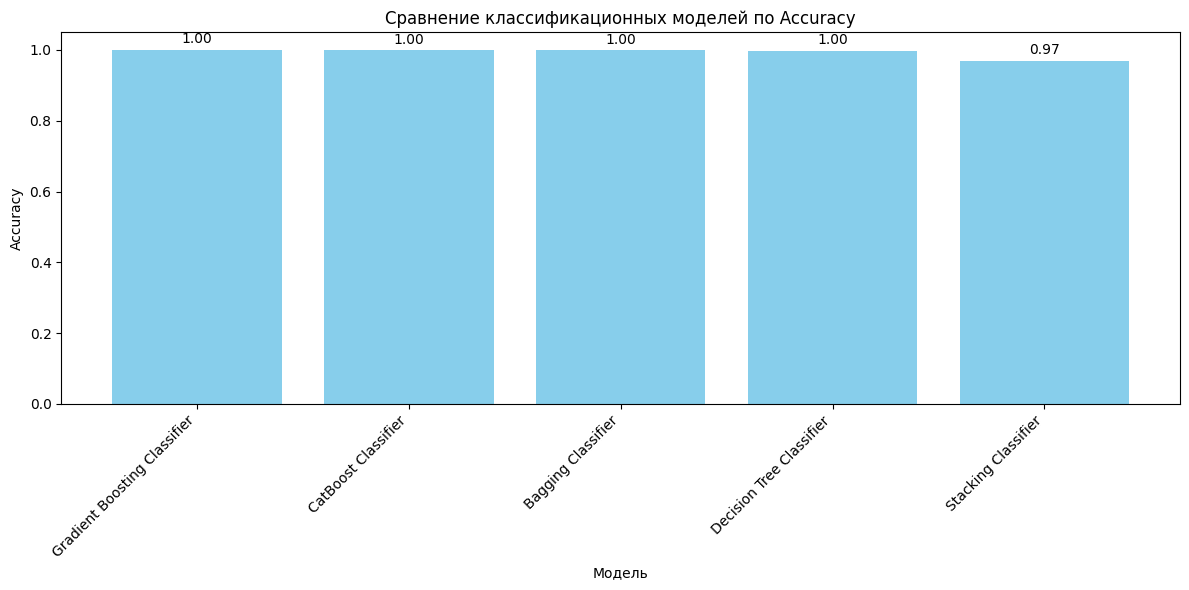

In [105]:
results = []
for model, name in zip(models1, model_names1):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='binary') 
    results.append({'Model': name, 'Accuracy': accuracy, 'F1': f1})

df = pd.DataFrame(results)
df = df.sort_values(by='Accuracy', ascending=False)
print("Таблица сравнения:")
print(df)

plt.figure(figsize=(12, 6))
plt.bar(df['Model'], df['Accuracy'], color='skyblue')
plt.xlabel('Модель')
plt.ylabel('Accuracy')
plt.title('Сравнение классификационных моделей по Accuracy')
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(df['Accuracy']):
    plt.text(i, v + 0.01, f'{v:.2f}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

Таблица сравнения:
                 Model  Accuracy        F1
0   XGBoost Classifier  0.999814  0.999814
1  LightGBM Classifier  0.999814  0.999814


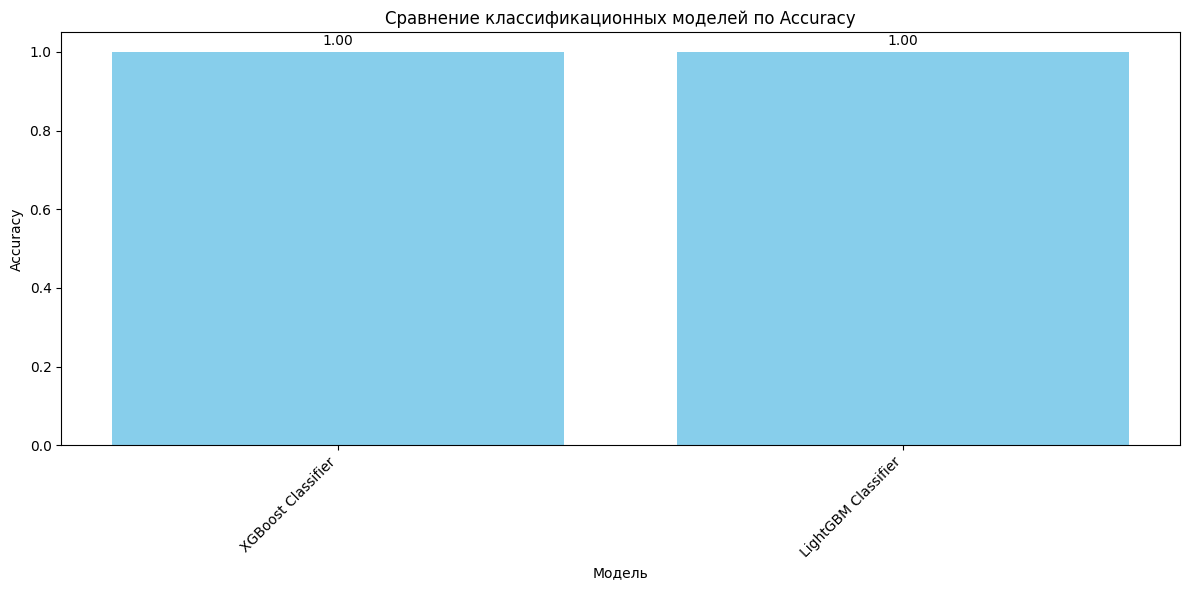

In [106]:
results = []
for model, name in zip(models2, model_names2):
    y_pred = model.predict(X_test_copy)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='binary') 
    results.append({'Model': name, 'Accuracy': accuracy, 'F1': f1})

df = pd.DataFrame(results)
df = df.sort_values(by='Accuracy', ascending=False)
print("Таблица сравнения:")
print(df)

plt.figure(figsize=(12, 6))
plt.bar(df['Model'], df['Accuracy'], color='skyblue')
plt.xlabel('Модель')
plt.ylabel('Accuracy')
plt.title('Сравнение классификационных моделей по Accuracy')
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(df['Accuracy']):
    plt.text(i, v + 0.01, f'{v:.2f}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

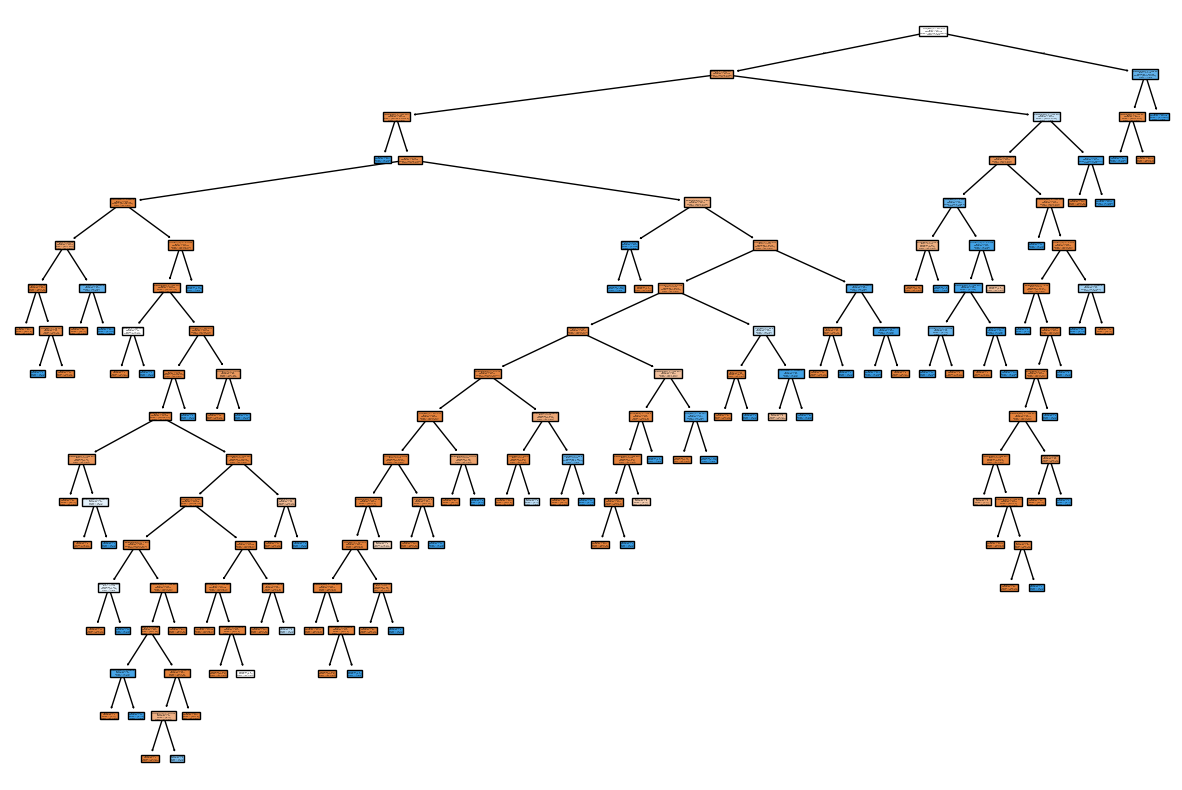

In [107]:
class_names = ['No Alarm', 'Alarm']
fig = plt.figure(figsize=(15, 10))
tree.plot_tree(reg, feature_names=X_train.columns, filled=True, class_names=class_names)
plt.show()

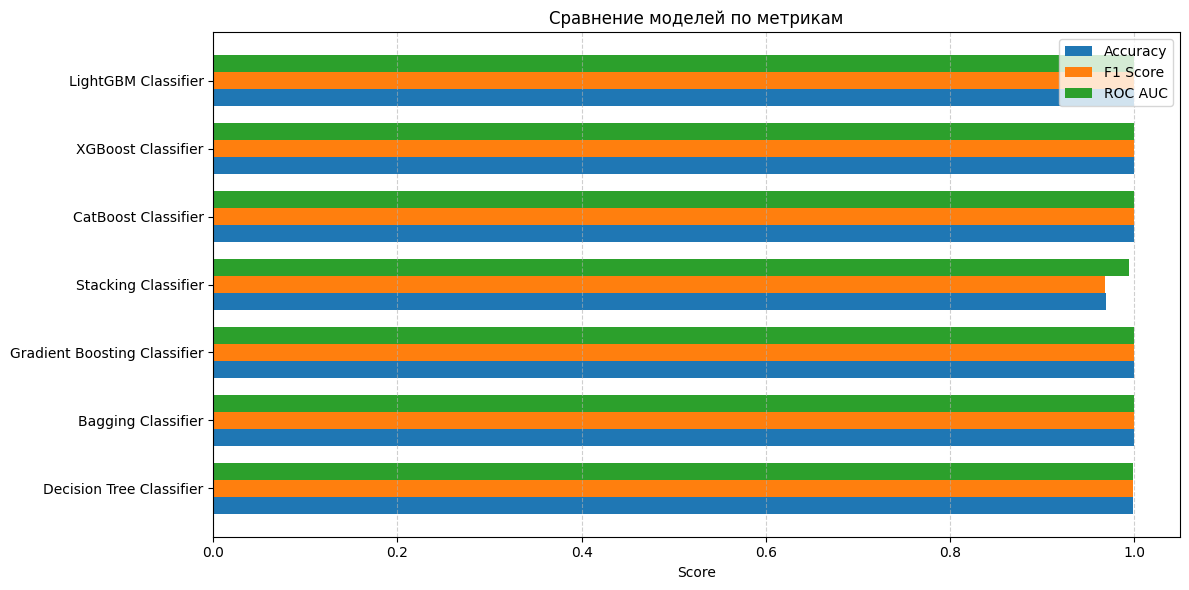

In [108]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

model_names1 = [
    'Decision Tree Classifier',
    'Bagging Classifier',
    'Gradient Boosting Classifier',
    'Stacking Classifier',
    'CatBoost Classifier',
]
model_names2 = [
    'XGBoost Classifier',
    'LightGBM Classifier'
]


def evaluate_model(model, X, y_true):
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1] if hasattr(
        model, "predict_proba") else None

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc = roc_auc_score(y_true, y_proba) if y_proba is not None else None

    return acc, f1, roc


acc1, f1s1, roc1 = [], [], []
for model in models1:
    acc, f1s, roc = evaluate_model(model, X_test, y_test)
    acc1.append(acc)
    f1s1.append(f1s)
    roc1.append(roc)

acc2, f1s2, roc2 = [], [], []
for model in models2:
    acc, f1s, roc = evaluate_model(model, X_test_copy, y_test)
    acc2.append(acc)
    f1s2.append(f1s)
    roc2.append(roc)

model_names = model_names1 + model_names2
all_acc = acc1 + acc2
all_f1 = f1s1 + f1s2
all_roc = roc1 + roc2

x = np.arange(len(model_names))
width = 0.25

plt.figure(figsize=(12, 6))
plt.barh(x - width, all_acc, height=width, label='Accuracy')
plt.barh(x, all_f1, height=width, label='F1 Score')
plt.barh(x + width, all_roc, height=width, label='ROC AUC')

plt.yticks(x, model_names)
plt.xlabel("Score")
plt.title("Сравнение моделей по метрикам")
plt.legend()
plt.tight_layout()
plt.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.show()

In [9]:
from cart import DecisionTree

X_train = X_train.to_numpy()
X_test = X_test.to_numpy()

tree = DecisionTree(max_depth=3, classification_task=True)
tree.fit(X_train, y_train)

y_pred = tree.predict(X_test)
print_classification_metrics(y_test, y_pred)

Accuracy: 0.9880666986308667
              precision    recall  f1-score   support

       False       0.97      0.99      0.98      5343
        True       1.00      0.99      0.99     13428

    accuracy                           0.99     18771
   macro avg       0.98      0.99      0.99     18771
weighted avg       0.99      0.99      0.99     18771

